In [1]:
import numpy as np
from scipy.optimize import bisect
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_ScipySp
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
# phic = (3 * beta)**(-0.5)
# M = phic / 2**0.5
Lambda = (1e-15)**0.25
nWaterfall = 1
psic = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5
beta = 1e4

def infPotFunc(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * ((1 - (psi / M)**2)**2 + 2 * (phi * psi / phic / M)**2 + beta * (phi - phic)**3))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * phi * (psi / phic / M)**2 + 3 * beta * (phi - phic)**2))
    
def infPotDerivFunc_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 * psi / M**2 * (1 - (psi / M)**2) + 4 * psi * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * (psi / phic / M)**2 + 6 * beta * (phi - phic)))

def infPotDeriv2Func_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psi / M / M)**2 + 4 * (phi / phic / M)**2))

def infPotDeriv2Func_phipsi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (8 * phi * psi / (phic * M)**2))

def eta_psi(Phi):
    return infPotDeriv2Func_psi(Phi) / infPotFunc(Phi)

def etaCl_phi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_phi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_phi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)

def etaCl_psi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_psi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_psi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psi]
infPotentialDeriv2Funcs = [[infPotDeriv2Func_phi, infPotDeriv2Func_phipsi], [infPotDeriv2Func_phipsi, infPotDeriv2Func_psi]]

nGrid = 2000

In [3]:
deltaPhiWell = 2 * (2 / 3 * Lambda**4 / beta) ** (1 / 3)
phiLargeEtaMax = bisect(lambda phi: etaCl_phi([phi, 0]) - 0.1, phic + 0.01 * deltaPhiWell, phic + 10 * deltaPhiWell) 
phiLargeEtaMin = phic - (phiLargeEtaMax - phic)

# 以下は1912.05399に準拠。下限はad hoc
phimax = phic + beta**(-1/3)
phimin = phic - beta**(-1/3)

In [4]:
psiLargeEtaMax = bisect(lambda psi: etaCl_psi([phiLargeEtaMax, psi]) - 0.1, 0.0001 * psic, 1000 * psic)
psiLargeEtaMin = -psiLargeEtaMax 

psimax = bisect(lambda psi: eta_psi([phic, psi]) - 1, 0, M)
psimin = -psimax

In [5]:
customGrid_phi = np.concatenate([phic - np.exp(np.linspace(np.log(phic - phimin), np.log(phic - phiLargeEtaMin), nGrid // 4, endpoint=False)),
                                 np.linspace(phiLargeEtaMin, phiLargeEtaMax, nGrid // 2),
                                 phic + np.exp(np.linspace(np.log(phiLargeEtaMax - phic), np.log(phimax - phic), nGrid // 4 + 1)[1:])])
customGrid_psi = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psiLargeEtaMax), nGrid // 4 + 1))[:-1],
                                 np.linspace(psiLargeEtaMin, psiLargeEtaMax, nGrid // 2),
                                 np.exp(np.linspace(np.log(psiLargeEtaMax), np.log(psimax), nGrid // 4 + 1))[1:]])

In [6]:
phic

0.0011582420658256308

In [7]:
customGrid_phi

array([-0.04525765, -0.04409325, -0.04295807, ...,  0.04527455,
        0.04640974,  0.04757413])

In [8]:
customGrid_psi

array([-1.93631193e-07, -1.90926941e-07, -1.88260458e-07, ...,
        1.88260458e-07,  1.90926941e-07,  1.93631193e-07])

<ipython-input-9-f50d7e0f0079>:7: RuntimeWarning: divide by zero encountered in log10
  cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))


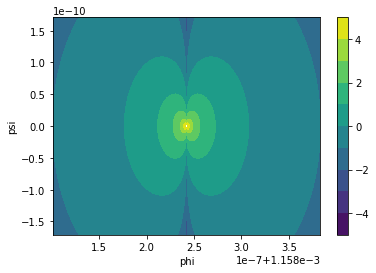

In [9]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_phi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

<ipython-input-10-fa15fc95bb6a>:7: RuntimeWarning: divide by zero encountered in log10
  cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))


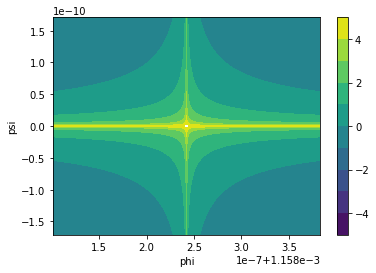

In [10]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_psi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

In [11]:
eigenValNum = 10

In [12]:
fpFinDiff_NeuDir = InfAdjFPFiniteDiff_ScipySp(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0OriFunc", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# # ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
# customGrid_phi_woEnd = customGrid_phi[1:-1]
# customGrid_psi_woEnd = customGrid_psi[1:-1]
# vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
# maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psi_woEnd)), False)
# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
#             maskMat[i1, i2] = True
#             fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuDir, eigVecs_NeuDir = eigs(fpFinDiff_NeuDir, eigenValNum, sigma=0, which='LM')
eigVecsSort_NeuDir = eigVecs_NeuDir.T[np.argsort(np.abs(eigVals_NeuDir))]
eigValsSort_NeuDir = eigVals_NeuDir[np.argsort(np.abs(eigVals_NeuDir))]

In [28]:
np.savetxt('C:/Users/koich/Desktop/Code/StochasticInflationDiffOpEigen/output/HybridPhiInflec_LogGrid_V0=1e-15_beta=1e4_nGrid2000/eigVals_NeuDir.csv', np.real(eigValsSort_NeuDir))
np.savetxt('C:/Users/koich/Desktop/Code/StochasticInflationDiffOpEigen/output/HybridPhiInflec_LogGrid_V0=1e-15_beta=1e4_nGrid2000/eigVecs_NeuDir.csv', np.real(eigVecsSort_NeuDir))

In [14]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_NeuDir)
np.set_printoptions()

  (0, 0)	4.053474591516927e+26
  (0, 1)	-0.04275332822937878
  (0, 1998)	-3.4467380515204326e-13
  (1, 0)	-0.04397302298868947
  (1, 1)	3.9419015112760624e+26
  (1, 2)	-0.04459323744569806
  (1, 1999)	-3.4466040098194785e-13
  (2, 1)	-0.04522484718164646
  (2, 2)	3.8333849316508914e+26
  (2, 3)	-0.04586279222726616
  (2, 2000)	-3.446473686023787e-13
  (3, 2)	-0.04651238368435174
  (3, 3)	3.7278421515683086e+26
  (3, 4)	-0.047168565140625895
  (3, 2001)	-3.44634697701008e-13
  (4, 3)	-0.047836651305256016
  (4, 4)	3.62519265122357e+26
  (4, 5)	-0.04851158942443022
  (4, 2002)	-3.446223782515416e-13
  (5, 4)	-0.049198697917598455
  (5, 5)	3.525358037657625e+26
  (5, 6)	-0.049892927793784084
  (5, 2003)	-3.4461040050578153e-13
  (6, 5)	-0.05059960128856888
  (6, 6)	3.4282619915176196e+26
  :	:
  (3991997, 3991997)	2.337040075294422e+22
  (3991997, 3991998)	-1.3260621503385415
  (3991998, 3990000)	-1.2307833730939719e-11
  (3991998, 3991997)	-1.3075423804151123
  (3991998, 3991998)	2.40360

In [15]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff_ScipySp(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = eigs(fpFinDiff_DirDir, eigenValNum, sigma=0, which='LM')
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(np.abs(eigVals_DirDir))]
eigValsSort_DirDir = eigVals_DirDir[np.argsort(np.abs(eigVals_DirDir))]

In [16]:
np.savetxt('C:/Users/koich/Desktop/Code/StochasticInflationDiffOpEigen/output/HybridPhiInflec_LogGrid_V0=1e-15_beta=1e4_nGrid2000/eigVals_DirDir.csv', np.real(eigValsSort_DirDir))
np.savetxt('C:/Users/koich/Desktop/Code/StochasticInflationDiffOpEigen/output/HybridPhiInflec_LogGrid_V0=1e-15_beta=1e4_nGrid2000/eigVecs_DirDir.csv', np.real(eigVecsSort_DirDir))

In [17]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_DirDir)
np.set_printoptions()

  (0, 0)	4.053474591516927e+26
  (0, 1)	-0.04275332822937878
  (0, 1998)	-3.4467380515204326e-13
  (1, 0)	-0.04397302298868947
  (1, 1)	3.9419015112760624e+26
  (1, 2)	-0.04459323744569806
  (1, 1999)	-3.4466040098194785e-13
  (2, 1)	-0.04522484718164646
  (2, 2)	3.8333849316508914e+26
  (2, 3)	-0.04586279222726616
  (2, 2000)	-3.446473686023787e-13
  (3, 2)	-0.04651238368435174
  (3, 3)	3.7278421515683086e+26
  (3, 4)	-0.047168565140625895
  (3, 2001)	-3.44634697701008e-13
  (4, 3)	-0.047836651305256016
  (4, 4)	3.62519265122357e+26
  (4, 5)	-0.04851158942443022
  (4, 2002)	-3.446223782515416e-13
  (5, 4)	-0.049198697917598455
  (5, 5)	3.525358037657625e+26
  (5, 6)	-0.049892927793784084
  (5, 2003)	-3.4461040050578153e-13
  (6, 5)	-0.05059960128856888
  (6, 6)	3.4282619915176196e+26
  :	:
  (3991997, 3991997)	2.337040075294422e+22
  (3991997, 3991998)	-1.3260621503385415
  (3991998, 3990000)	-6.009333897048002e-12
  (3991998, 3991997)	-1.3075423804151123
  (3991998, 3991998)	2.403606

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


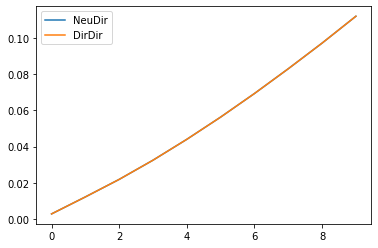

In [18]:
ax = plt.gca()
plt.plot(eigValsSort_NeuDir, label = "NeuDir")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

In [19]:
print(eigValsSort_NeuDir)
print(eigValsSort_DirDir)

[0.00273055+0.j 0.0121383 +0.j 0.02183931+0.j 0.03246837+0.j
 0.04402296+0.j 0.05632766+0.j 0.0693797 +0.j 0.08308865+0.j
 0.09728681+0.j 0.11215892+0.j]
[0.00273055+0.j 0.0121383 +0.j 0.02183931+0.j 0.03246837+0.j
 0.04402296+0.j 0.05632766+0.j 0.0693797 +0.j 0.08308865+0.j
 0.09728681+0.j 0.11215892+0.j]


c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


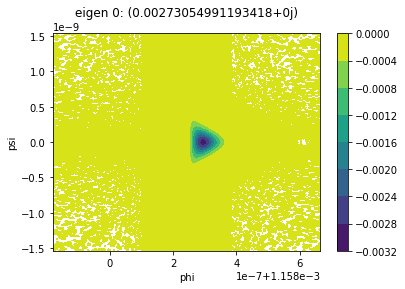

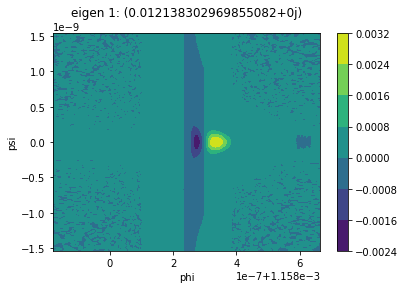

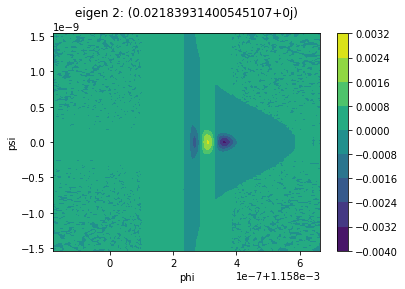

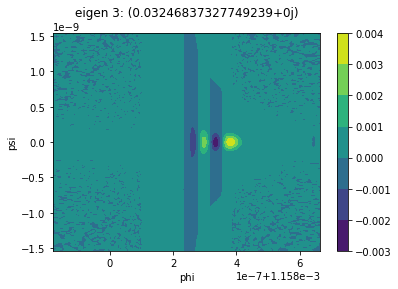

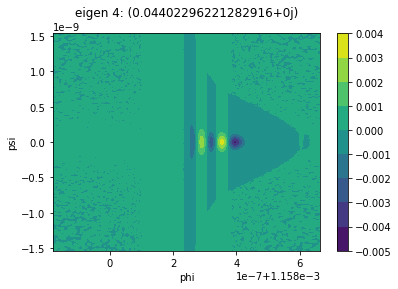

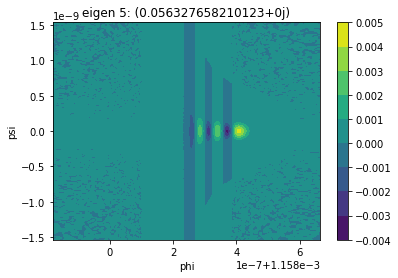

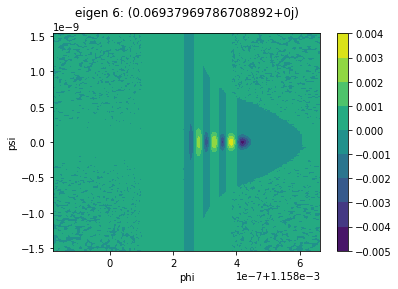

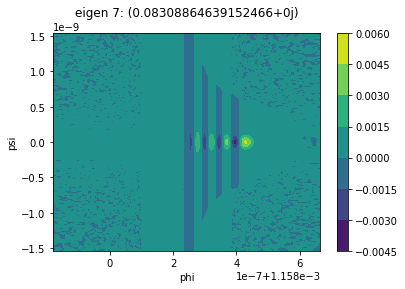

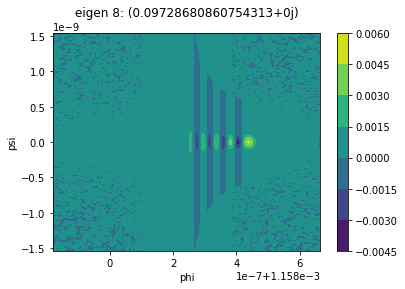

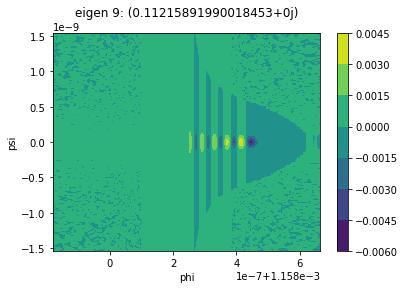

In [20]:
# 固有関数のプロット
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psi_woEnd = customGrid_psi[1:-1]

for iEig in range(eigenValNum):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    ax1.set_title("eigen " + str(iEig) + ": " + str(eigValsSort_NeuDir[iEig]))
    plt.show()

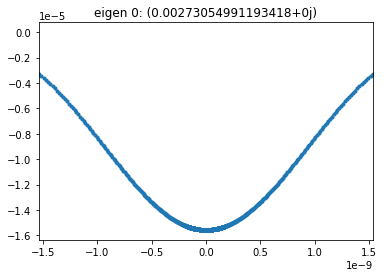

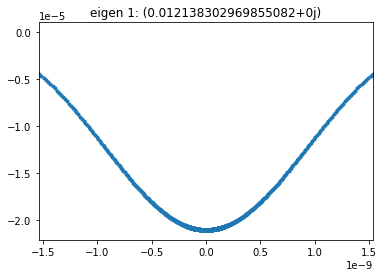

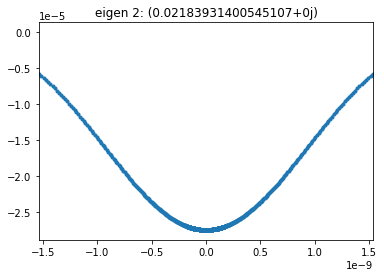

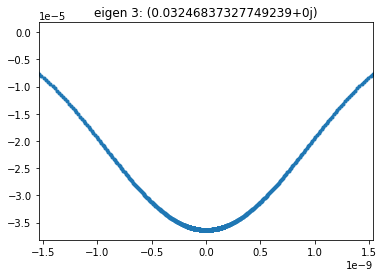

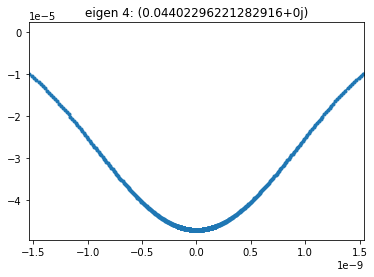

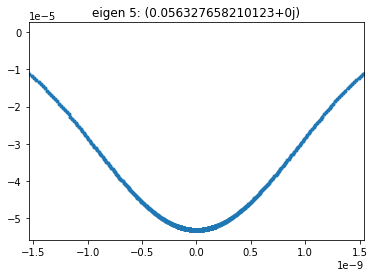

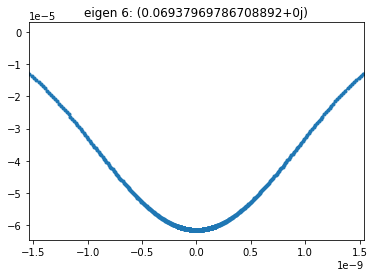

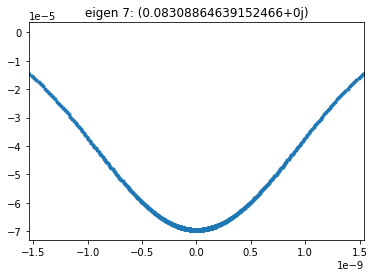

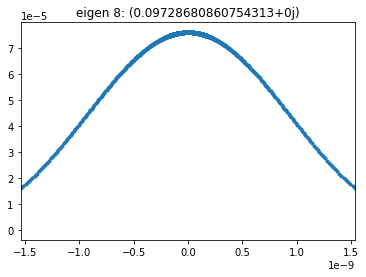

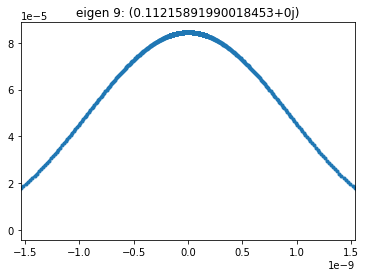

In [21]:
for iEig in range(eigenValNum):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[nGrid // 2,:], marker='.')
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    ax.set_title("eigen " + str(iEig) + ": " + str(eigValsSort_NeuDir[iEig]))
    plt.show()

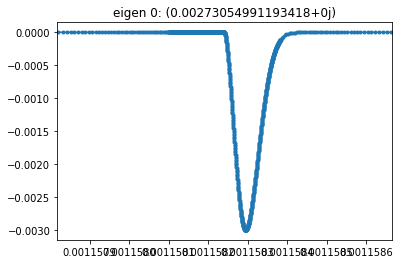

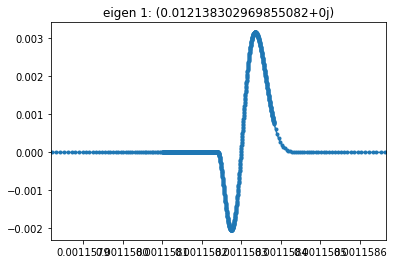

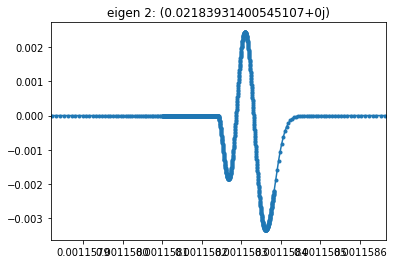

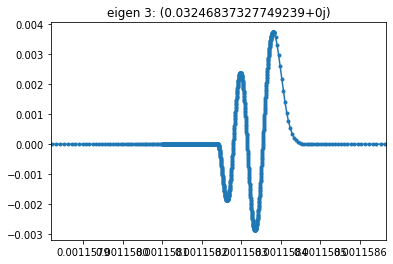

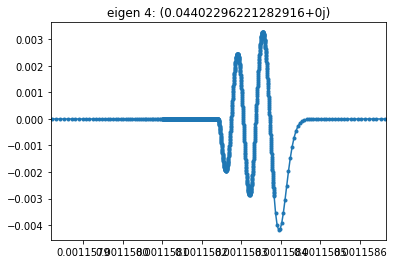

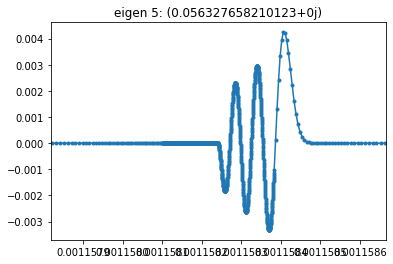

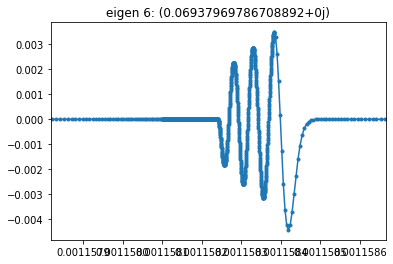

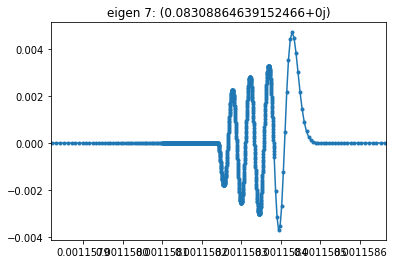

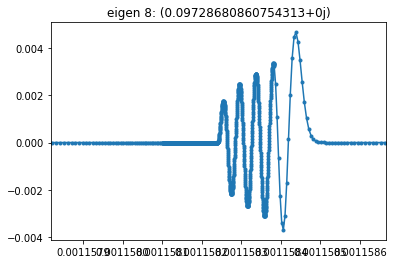

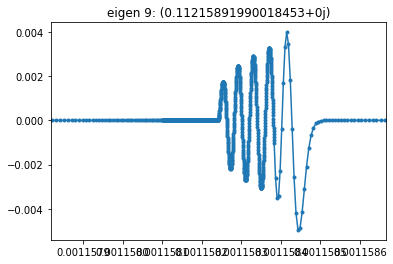

In [22]:
for iEig in range(eigenValNum):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    ax.set_title("eigen " + str(iEig) + ": " + str(eigValsSort_NeuDir[iEig]))
    plt.show()

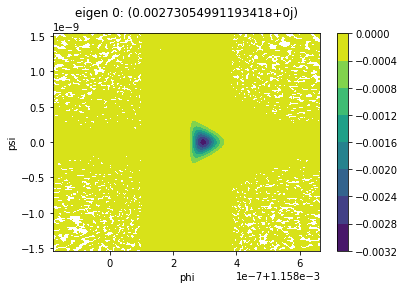

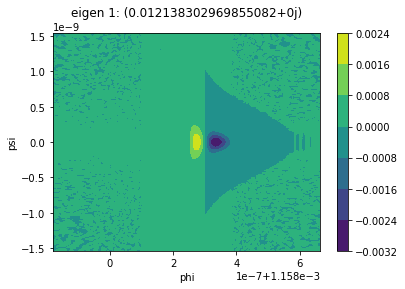

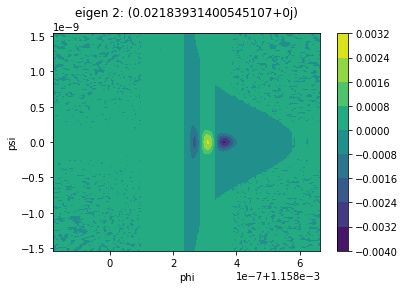

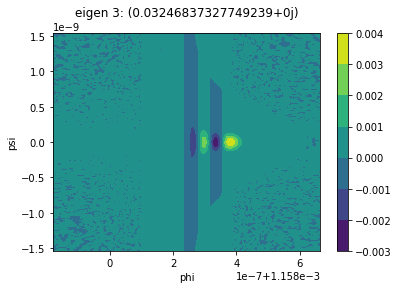

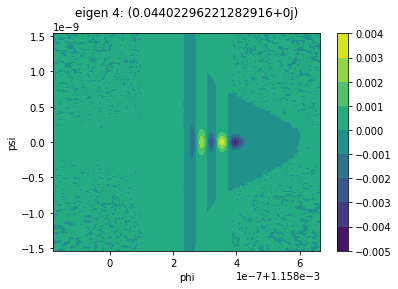

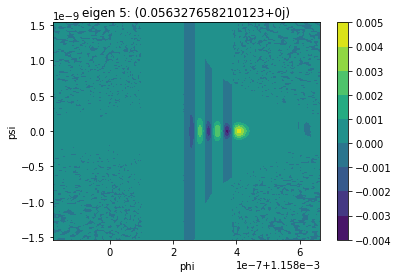

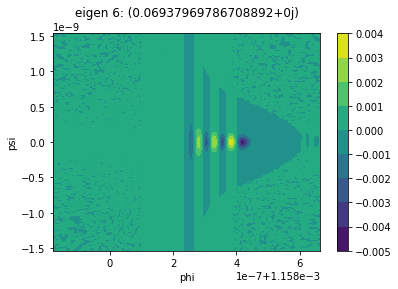

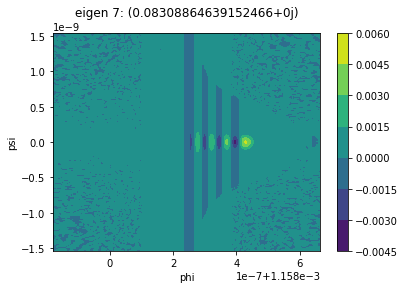

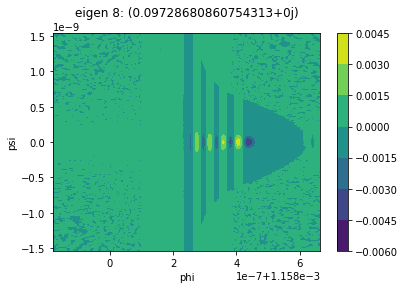

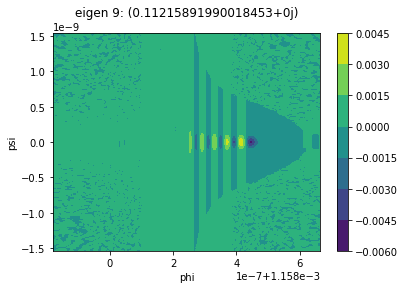

In [23]:
# 固有関数のプロット
for iEig in range(eigenValNum):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    ax1.set_title("eigen " + str(iEig) + ": " + str(eigValsSort_NeuDir[iEig]))
    plt.show()

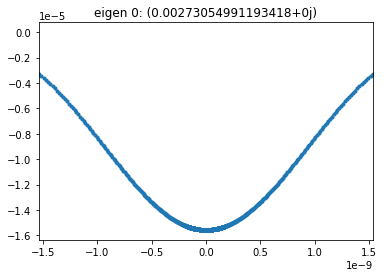

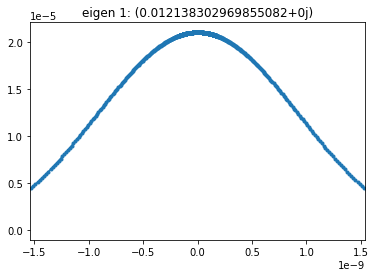

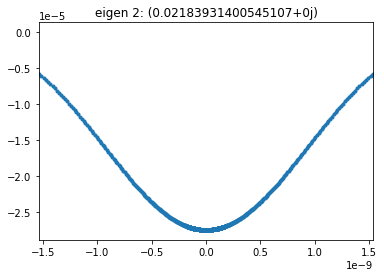

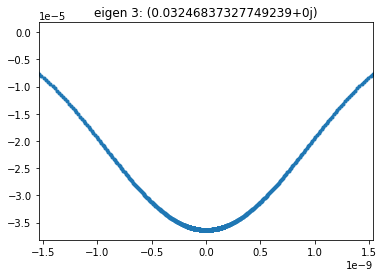

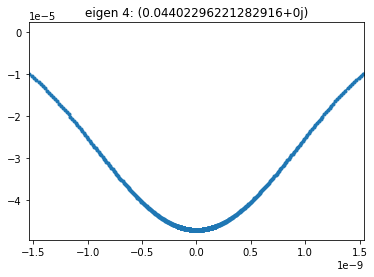

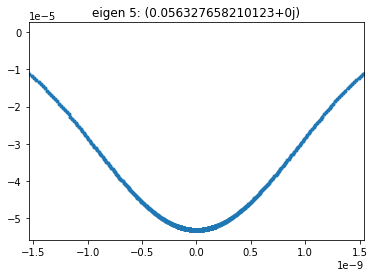

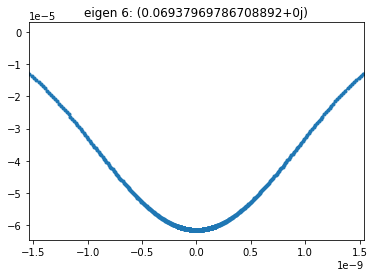

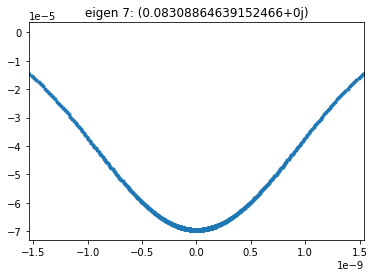

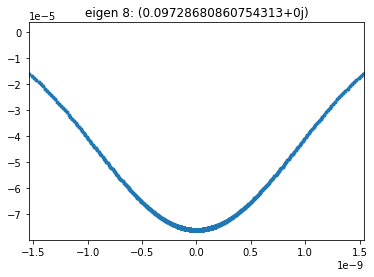

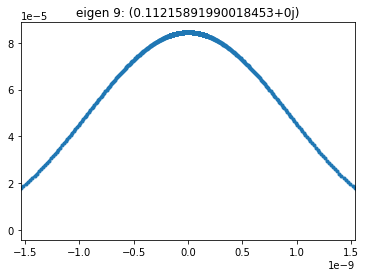

In [24]:
for iEig in range(eigenValNum):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[nGrid//2,:],marker=".")
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    ax.set_title("eigen " + str(iEig) + ": " + str(eigValsSort_NeuDir[iEig]))
    plt.show()

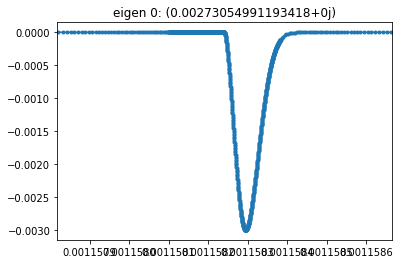

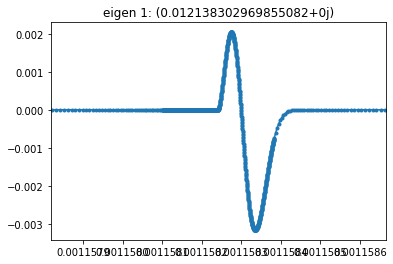

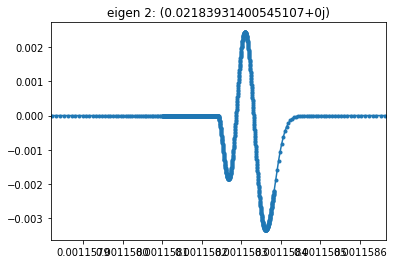

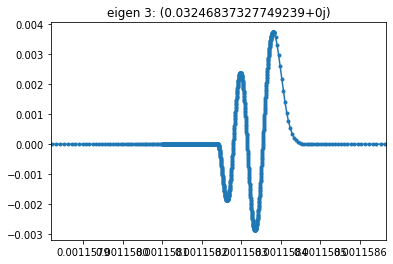

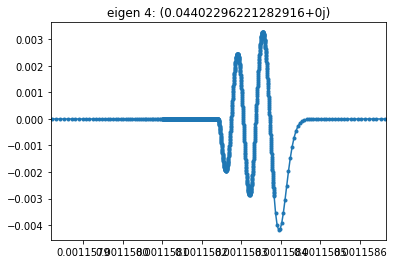

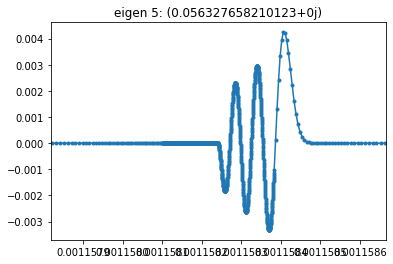

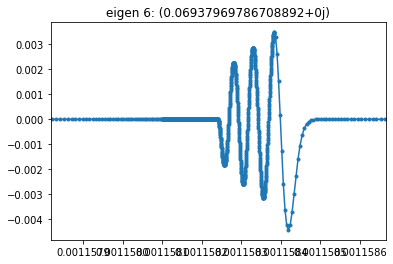

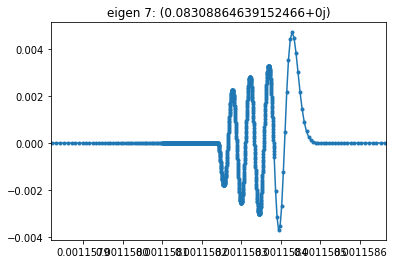

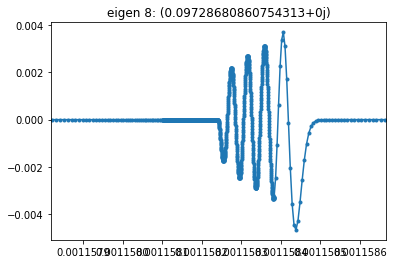

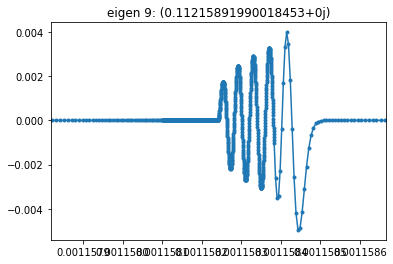

In [25]:
for iEig in range(eigenValNum):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    ax.set_title("eigen " + str(iEig) + ": " + str(eigValsSort_NeuDir[iEig]))
    plt.show()

Gaussianとのオーバーラップ

In [26]:
muPhi = 0.5 * (phiLargeEtaMax + phiLargeEtaMin)
sigmaPhi = (phiLargeEtaMax - phiLargeEtaMin) / 2
muPsi = 0.5 * (psiLargeEtaMax + psiLargeEtaMin)
sigmaPsi = (psiLargeEtaMax - psiLargeEtaMin) / 2
trialVec = np.zeros((nGrid - 2)**2)
normFacTrial = 0

for iPhi in range(nGrid - 2):
    phi = customGrid_phi[iPhi + 1]
    delphi = customGrid_phi[iPhi + 1] - customGrid_phi[iPhi]
    for iPsi in range(nGrid - 2):
        psi = customGrid_psi[iPsi + 1]
        delpsi = customGrid_psi[iPsi + 1] - customGrid_psi[iPsi]
        trialVal = np.exp(- 0.5 * (((phi - muPhi) / sigmaPhi)**2 + ((psi - muPsi) / sigmaPsi)**2))
        trialVec[iPhi * (nGrid - 2) + iPsi] = trialVal
        normFacTrial += trialVal**2 * delphi * delpsi

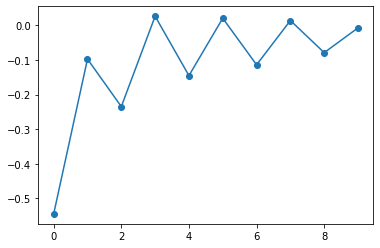

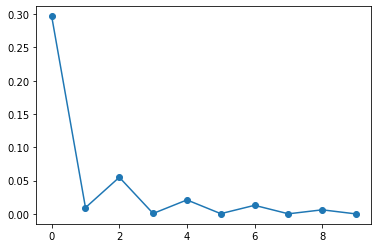

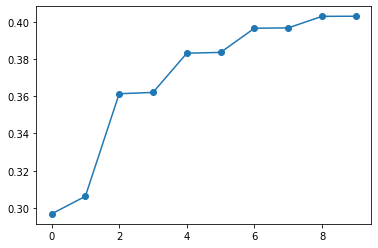

In [27]:
# 各固有ベクトルの寄与度
contriEachEigVec = []

for ev in eigVecsSort_DirDir:
    contri = 0
    normFacEv = 0
    for iPhi in range(nGrid - 2):
        delphi = customGrid_phi[iPhi + 1] - customGrid_phi[iPhi]
        for iPsi in range(nGrid - 2):
            delpsi = customGrid_psi[iPsi + 1] - customGrid_psi[iPsi]
            normFacEv += ev[iPhi * (nGrid - 2) + iPsi]**2 * delphi * delpsi
            contri += ev[iPhi * (nGrid - 2) + iPsi] * trialVec[iPhi * (nGrid - 2) + iPsi] * delphi * delpsi

    contriEachEigVec += [contri / np.sqrt(normFacEv) / np.sqrt(normFacTrial)]

contriEachEigVec = np.array(contriEachEigVec)

ax = plt.gca()
plt.plot(contriEachEigVec, marker='o')
plt.show()

ax = plt.gca()
plt.plot(contriEachEigVec**2, marker='o')
plt.show()

ax = plt.gca()
plt.plot(np.cumsum(contriEachEigVec**2), marker='o')
plt.show()